In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import scipy as sp

try:
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath}",
    })
except Exception as e:
    print(f"Could not enable LaTeX rendering: {e}\nFalling back to default.")

In [129]:
def flexural_moment(x, k, l):
    res = np.zeros_like(x)
    for i in range(len(x)):
        if x[i] <= k*l:
            res[i] = (1-k) * x[i]
        else:
            res[i] = (1-k) * k * l - k * (x[i] - k*l)
    return res

def deflection(x, k, l):
    res = np.zeros_like(x)
    for i in range(len(x)):
        if x[i] <= k*l:
            # print(f"Calculating deflection for x={x[i]:.3f} (<= {k*l:.3f})")
            res[i] = (1-k) * l * x[i] * (l**2 - ((1-k)*l)**2 - x[i]**2) / (6 * l)
        else:
            # print(f"Calculating deflection 2 for x={x[i]:.3f} (<= {k*l:.3f})")
            res[i] = (1-k) * l * x[i] * (l**2 - ((1-k)*l)**2 - x[i]**2) / (6 * l) + (x[i] - k*l)**3 / 6
    return -res

def deflection_n(x, k, l):
    res = np.zeros_like(x)
    a = k*l
    b = (1-k)*l
    for i in range(len(x)):
        if x[i] <= k*l:
            # print(f"Calculating deflection for x={x[i]:.3f} (<= {k*l:.3f})")
            res[i] = (2 * a * x[i] * l - 3 * a**2 * x[i] +  a**3 * x[i] / l + a * x[i]**3 / l - x[i]**3 / 3) / 6
        else:
            # print(f"Calculating deflection 2 for x={x[i]:.3f} (<= {k*l:.3f})")
            res[i] = (-a**3 + 2 * a * x[i] * l + a**3 * x[i] / l - 3 * a * x[i]**2 + a * x[i]**3 / l) / 6
    return -res

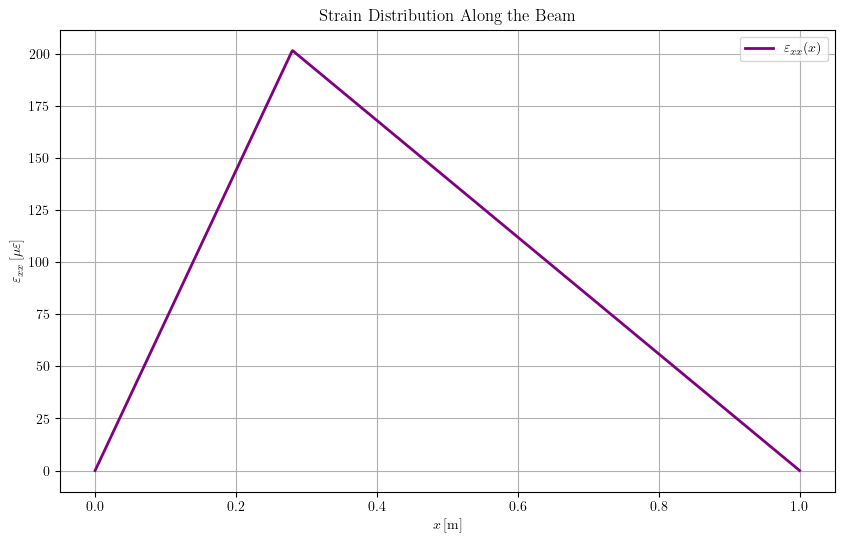

In [130]:
k = 0.28
l = 1
x = np.linspace(0, l, 1000)
M = flexural_moment(x, k, l)
plt.figure(figsize=(10, 6))
plt.plot(x, M*1e3, label='$\\varepsilon_{xx}(x)$', color='purple', linewidth=2)
plt.title('Strain Distribution Along the Beam')    
plt.xlabel('$x \\left[\\mathrm{m}\\right]$')
plt.ylabel('$\\varepsilon_{xx} \\left[\\mathrm{\\mu\\varepsilon}\\right]$')
plt.legend()
plt.grid(True)
# plt.savefig("beam_strain.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

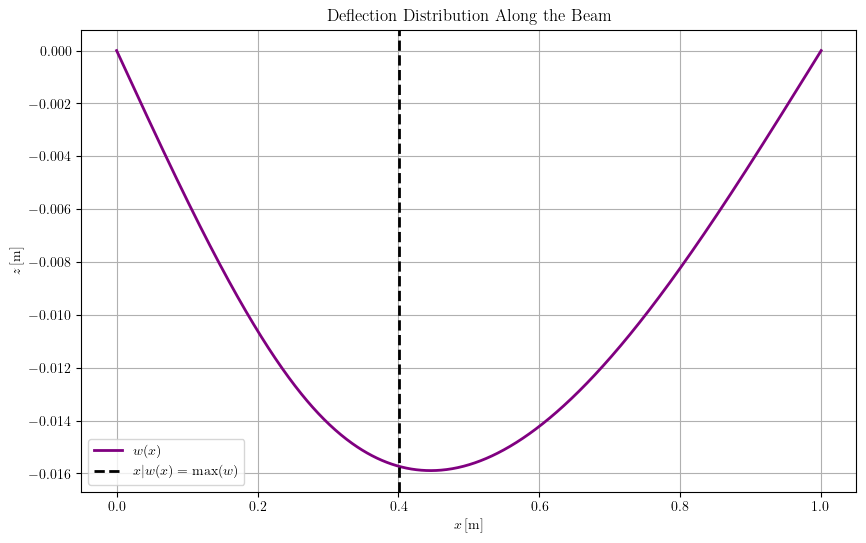

In [131]:
w = deflection(x, k, l)
plt.figure(figsize=(10, 6))
plt.plot(x, w, label='$w(x)$', color='purple', linewidth=2)
plt.axvline(x=np.sqrt((l**2 - ((1-k)*l)**2)/3), color='black', linestyle='--', linewidth=2, label='$x | w(x) = \\max(w)$')
plt.title('Deflection Distribution Along the Beam')    
plt.xlabel('$x \\left[\\mathrm{m}\\right]$')
plt.ylabel('$z \\left[\\mathrm{m}\\right]$')
plt.legend()
plt.grid(True)
plt.show()

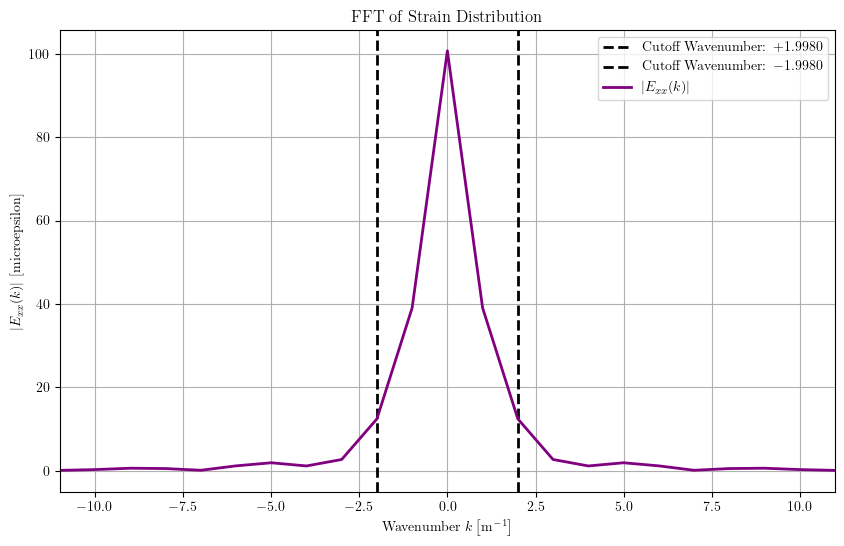

In [132]:
f = np.fft.fftshift(np.fft.fft(M))
frequencies = np.fft.fftshift(np.fft.fftfreq(len(M), d=(x[1] - x[0])))
cumulative_energy = np.cumsum(np.abs(f)**2) 
cutoff_frequency = frequencies[np.argmax(cumulative_energy >= 0.99 * cumulative_energy[-1])]

# limit the x-axis to the cutoff frequency for better visualization of the relevant part of the spectrum
plt.figure(figsize=(10, 6))
plt.axvline(x=cutoff_frequency, color='black', linestyle='--', linewidth=2, label=f'Cutoff Wavenumber: $+{cutoff_frequency:.4f}$')
plt.axvline(x=-cutoff_frequency, color='black', linestyle='--', linewidth=2, label=f'Cutoff Wavenumber: $-{cutoff_frequency:.4f}$')
plt.plot(frequencies, np.abs(f), label='$|E_{xx}(k)|$', color='purple', linewidth=2)
plt.xlim(-cutoff_frequency*5.5, cutoff_frequency*5.5)  # limit x-axis to 1.5 times the cutoff frequency for better visualization
plt.title('FFT of Strain Distribution')
plt.xlabel('Wavenumber $k \\left[\\mathrm{m}^{-1}\\right]$')
plt.ylabel('$|E_{xx}(k)|$ [microepsilon]')
plt.legend()
plt.grid(True)
# plt.savefig("beam_strain_fft.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

In [133]:
# # use nyquist wavenumber cutoff to find the spatial resolution limit
# # delta = 1 / (2 * cutoff_frequency)
# delta = 100e-3
# n = int(l / delta)  # select points that are multiples of delta
# x_sampled = x[::int(np.ceil( len(x) / n ))]  # ensure the last point is included
# strain = M[::int(np.ceil( len(x) / n ))]  # ensure the last point is included

# w_int_f = np.cumsum(np.cumsum(strain) * delta) * delta # double integral
# w_int_f = w_int_f - w_int_f[-1] / np.max(x_sampled) * x_sampled # boudary condition w[a] == 0

# x_sampled_b = l - x[::-1][::int(np.ceil( len(x) / n ))]  # ensure the last point is included and maintain original order
# strain_b = M[::-1][::int(np.ceil( len(x) / n ))]

# w_int_b = np.cumsum(np.cumsum(strain_b) * delta) * delta # double integral
# w_int_b = w_int_b - w_int_b[-1] / np.max(x_sampled_b) * x_sampled_b # boudary condition w[a] == 0   

# w_int = (w_int_b + w_int_f) / 2

# plt.figure(figsize=(10, 6))
# plt.plot(x_sampled, w_int_f, label='Sampled Points Forward', color='purple', linewidth=2)
# plt.plot(l - x_sampled_b, w_int_b, label='Sampled Points Backward', color='orange', linewidth=2)
# plt.plot(x_sampled, w_int, label='Sampled Points Average', color='red', linewidth=2)
# plt.plot(x, w, label='Reference Points', color='blue', linewidth=2)
# plt.title('Direct Integration of Sampled Points vs Reference Deflection')
# plt.xlabel('Position along the beam')
# plt.ylabel('Deflection')
# plt.legend()
# plt.grid(True)
# plt.show()

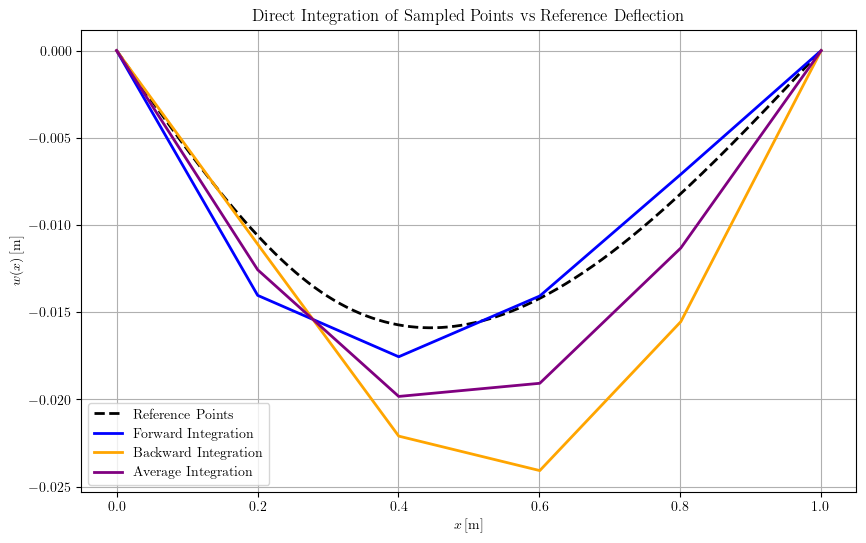

In [ ]:
delta = 1 / (2 * cutoff_frequency)
# delta = 0.25
# n = int(np.ceil(l / delta)) +2 # select points that are multiples of delta
n = 5
# x_sampled = x[::int(np.ceil( len(x) / n ))]
x_sampled = np.append(x[::int(np.ceil( len(x) / n ))], l)
strain = np.append(M[::int(np.ceil( len(x) / n ))], 0)

w_int_f = np.cumsum(np.cumsum(strain) * delta) * delta # double integral
w_int_f = w_int_f - w_int_f[-1] / np.max(x_sampled) * x_sampled # boudary condition w[a] == 0

w_int_b = np.cumsum(np.cumsum(strain[::-1]) * delta) * delta # double integral
w_int_b = w_int_b - w_int_b[-1] / np.max(x_sampled) * x_sampled # boudary condition w[a] == 0   

w_avg = (w_int_b[::-1] + w_int_f) / 2

plt.figure(figsize=(10, 6))
plt.plot(x, w, label='Reference Points', color='black', linewidth=2, linestyle='--')
plt.plot(x_sampled, w_int_f, label='Forward Integration', color='blue', linewidth=2)
plt.plot(x_sampled, w_int_b[::-1], label='Backward Integration', color='orange', linewidth=2)
plt.plot(x_sampled, w_avg, label='Average Integration', color='purple', linewidth=2)
plt.title('Direct Integration of Sampled Points vs Reference Deflection')
plt.xlabel('$x \\left[\\mathrm{m}\\right]$')
plt.ylabel('$w(x) \\left[\\mathrm{m}\\right]$')
plt.legend()
plt.grid(True)
plt.show()

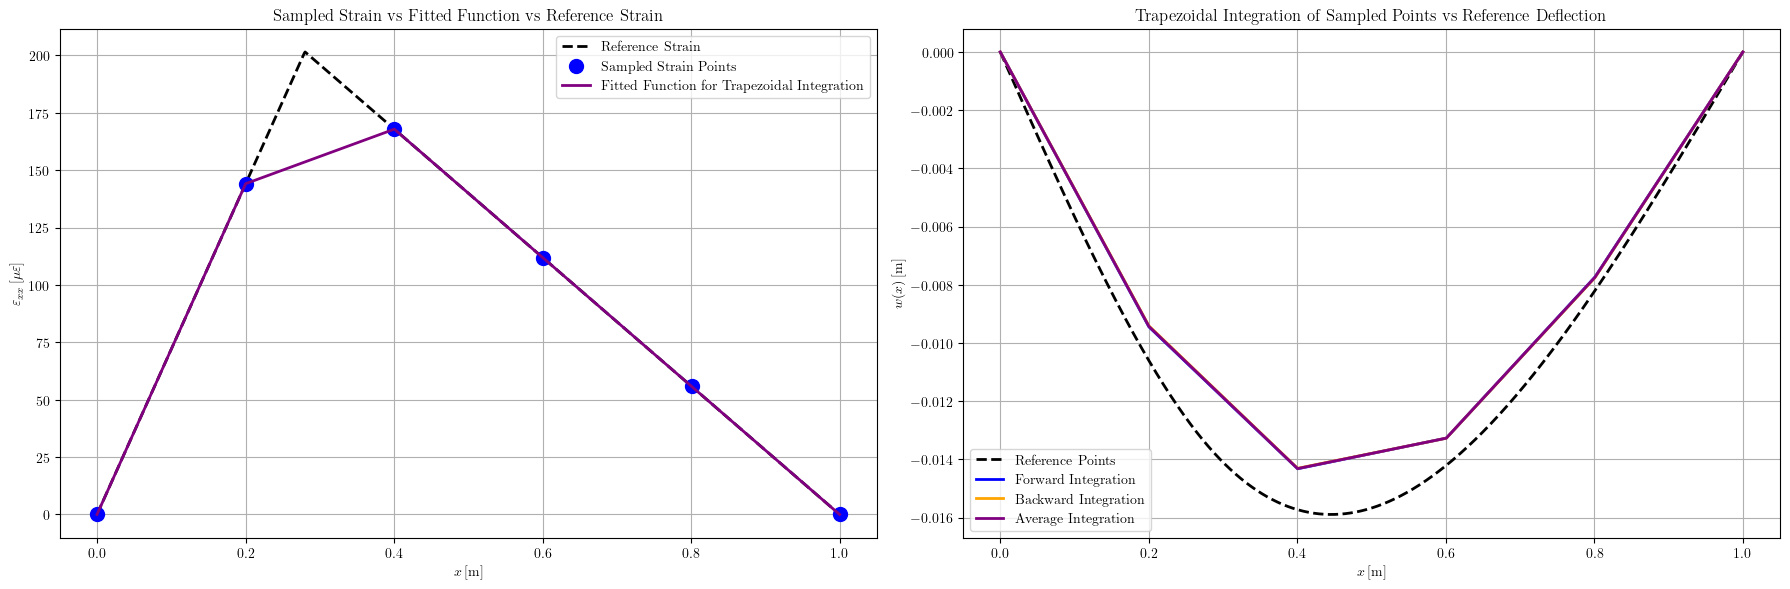

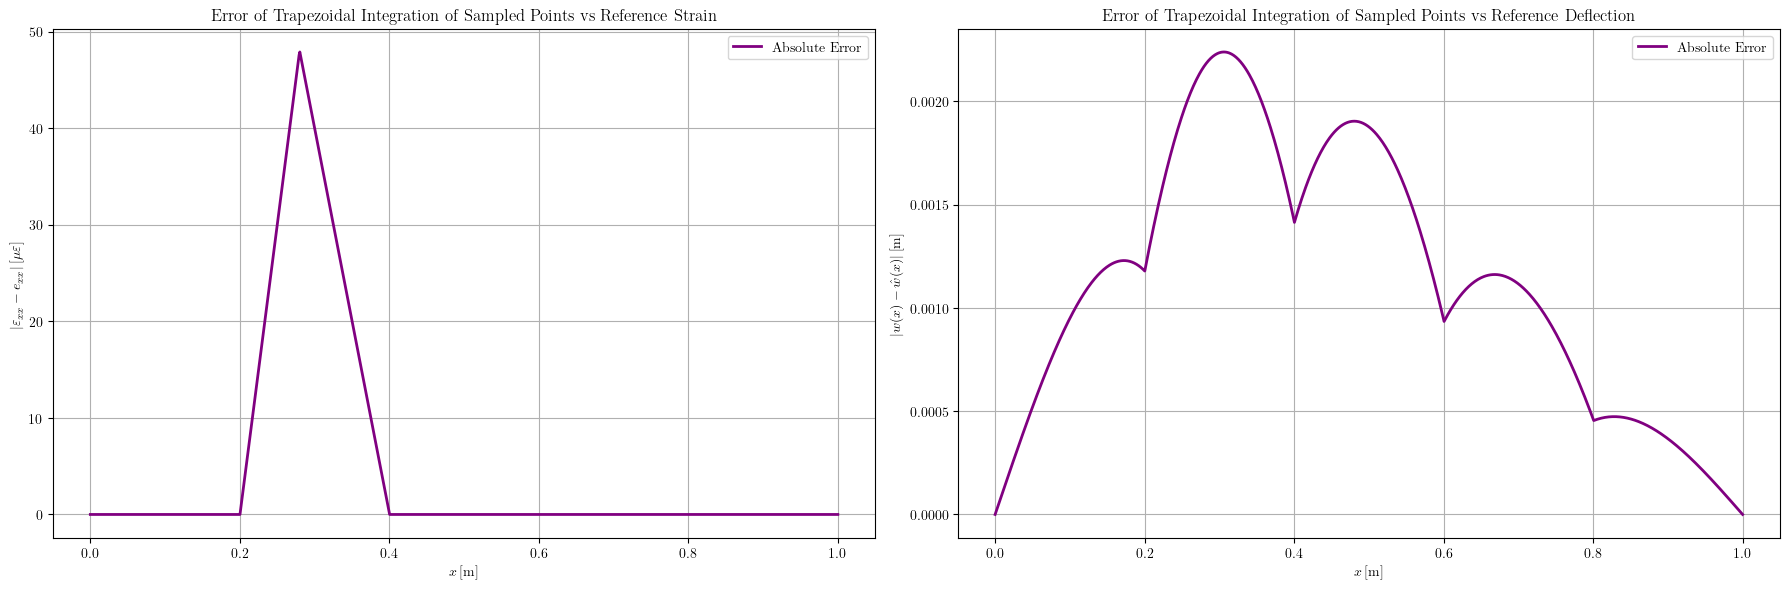

In [142]:
# delta = 1 / (2 * cutoff_frequency)
# delta = 0.25
# n = 5  # select points that are multiples of delta
x_sampled = np.append(x[::int(np.ceil( len(x) / n ))], l)
strain = np.append(M[::int(np.ceil( len(x) / n ))], 0)

w_int_f = sp.integrate.cumulative_trapezoid(sp.integrate.cumulative_trapezoid(strain, x_sampled, initial=0), x_sampled, initial=0) # double integral
w_int_f = w_int_f - w_int_f[-1] / np.max(x_sampled) * x_sampled # boudary condition w[a] == 0

w_int_b = sp.integrate.cumulative_trapezoid(sp.integrate.cumulative_trapezoid(strain[::-1], x_sampled, initial=0), x_sampled, initial=0) # double integral
w_int_b = w_int_b - w_int_b[-1] / np.max(x_sampled) * x_sampled # boudary condition w[a] == 0   

w_avg = (w_int_b[::-1] + w_int_f) / 2

w_avg_interp = sp.interpolate.interp1d(x_sampled, w_avg, kind='linear')(x)
error_deflection = np.abs(w - w_avg_interp)

fig, ax = plt.subplots(1, 2,figsize=(18, 6))

ax[0].set_title('Sampled Strain vs Fitted Function vs Reference Strain')
ax[0].plot(x, M*1e3, label='Reference Strain', color='black', linewidth=2, linestyle='--')
ax[0].plot(x_sampled, strain*1e3, label='Sampled Strain Points', color='blue', linestyle='None', marker='o', markersize=10)
ax[0].plot(x, sp.interpolate.interp1d(x_sampled, strain*1e3, kind='linear')(x), label='Fitted Function for Trapezoidal Integration', color='purple', linewidth=2)
ax[0].set_xlabel('$x \\left[\\mathrm{m}\\right]$')
ax[0].set_ylabel('$\\varepsilon_{xx} \\left[\\mathrm{\\mu\\varepsilon}\\right]$')
ax[0].legend()
ax[0].grid(True)
ax[1].plot(x, w, label='Reference Points', color='black', linewidth=2, linestyle='--')
ax[1].plot(x_sampled, w_int_f, label='Forward Integration', color='blue', linewidth=2)
ax[1].plot(x_sampled, w_int_b[::-1], label='Backward Integration', color='orange', linewidth=2)
ax[1].plot(x_sampled, w_avg, label='Average Integration', color='purple', linewidth=2)
ax[1].set_title('Trapezoidal Integration of Sampled Points vs Reference Deflection')
ax[1].set_xlabel('$x \\left[\\mathrm{m}\\right]$')
ax[1].set_ylabel('$w(x) \\left[\\mathrm{m}\\right]$')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.savefig("beam_sampled_trapezoidal_integration.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

fig, ax = plt.subplots(1, 2,figsize=(18, 6))

ax[0].plot(x, np.abs(M*1e3 - sp.interpolate.interp1d(x_sampled, strain*1e3, kind='linear')(x)), label='Absolute Error', color='purple', linewidth=2)
ax[0].set_title('Error of Trapezoidal Integration of Sampled Points vs Reference Strain')
ax[0].set_xlabel('$x \\left[\\mathrm{m}\\right]$')
ax[0].set_ylabel('$\\left|\\varepsilon_{xx} - e_{xx}\\right| \\left[\\mathrm{\\mu\\varepsilon}\\right]$')
ax[0].legend()
ax[0].grid(True)
ax[1].plot(x, error_deflection, label='Absolute Error', color='purple', linewidth=2)
ax[1].set_title('Error of Trapezoidal Integration of Sampled Points vs Reference Deflection')
ax[1].set_xlabel('$x \\left[\\mathrm{m}\\right]$')
ax[1].set_ylabel('$\\left|w(x) - \\hat{w}(x)\\right| \\left[\\mathrm{m}\\right]$')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.savefig("beam_sampled_trapezoidal_integration_error.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

# plt.figure(figsize=(10, 6))
# plt.plot(x, w, label='Reference Points', color='blue', linewidth=2)
# plt.plot(x_sampled, w_int_f, label='Forward Integration', color='green', linewidth=2)
# plt.plot(x_sampled, w_int_b[::-1], label='Backward Integration', color='orange', linewidth=2)
# plt.plot(x_sampled, w_avg, label='Average Integration', color='red', linewidth=2)
# plt.title('Trapezoidal Integration of Sampled Points vs Reference Deflection')
# plt.xlabel('Position along the beam')
# plt.ylabel('Deflection')
# plt.legend()
# plt.grid(True)
# plt.show()

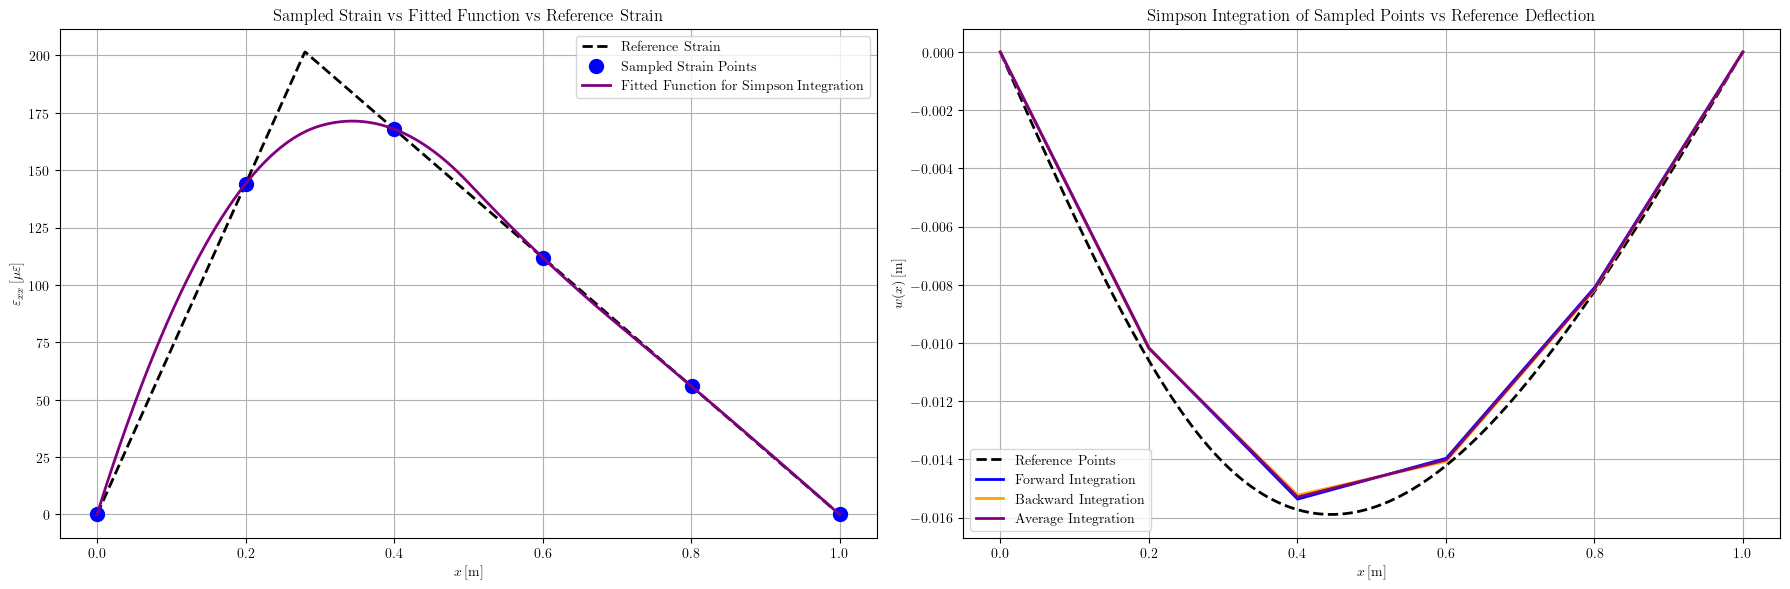

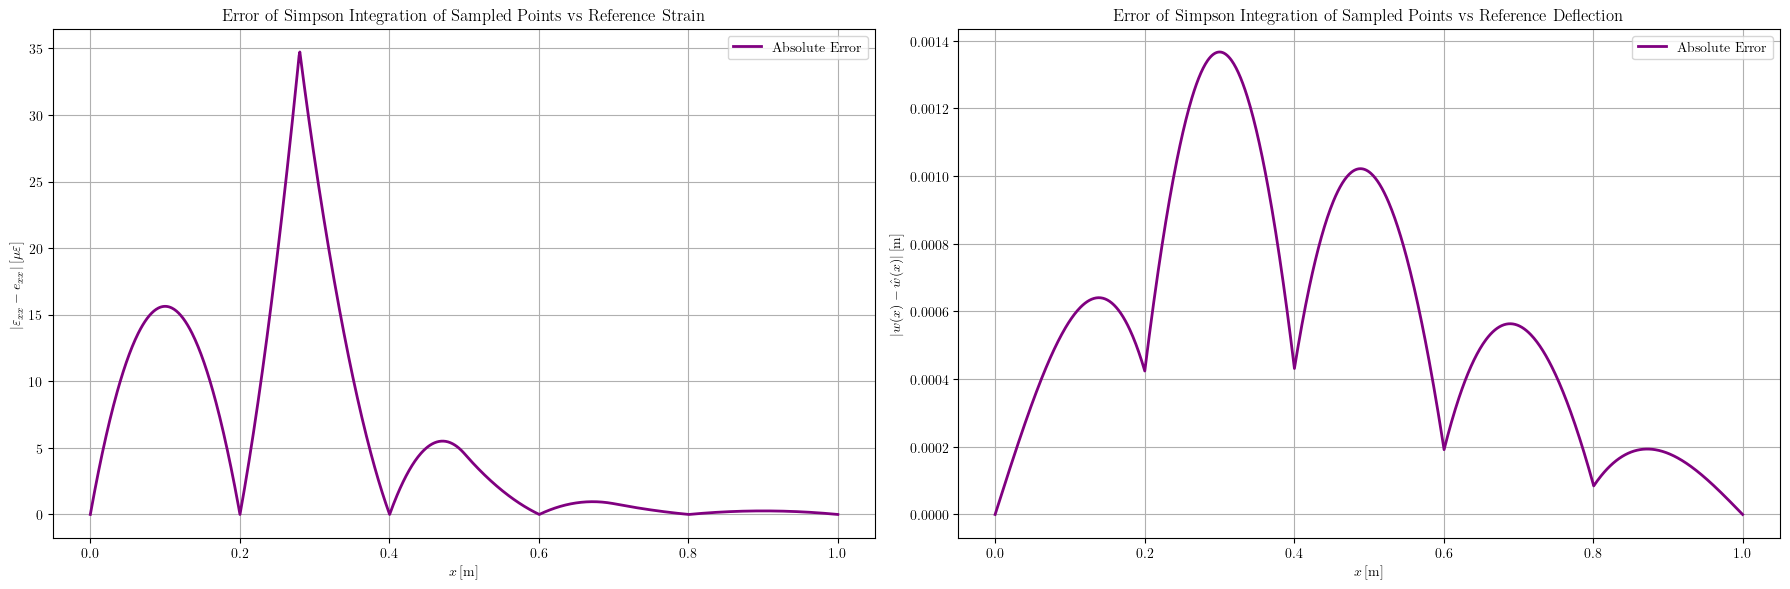

<Figure size 640x480 with 0 Axes>

In [145]:
# delta = 1 / (2 * cutoff_frequency)
# delta = 0.25
# n = int(l / delta)  # select points that are multiples of delta
x_sampled = np.append(x[::int(np.ceil( len(x) / n ))], l)
strain = np.append(M[::int(np.ceil( len(x) / n ))], 0)

w_int_f = sp.integrate.cumulative_simpson(sp.integrate.cumulative_simpson(strain, x=x_sampled, initial=0), x=x_sampled, initial=0) # double integral
w_int_f = w_int_f - w_int_f[-1] / np.max(x_sampled) * x_sampled # boudary condition w[a] == 0

w_int_b = sp.integrate.cumulative_simpson(sp.integrate.cumulative_simpson(strain[::-1], x=x_sampled, initial=0), x=x_sampled, initial=0) # double integral
w_int_b = w_int_b - w_int_b[-1] / np.max(x_sampled) * x_sampled # boudary condition w[a] == 0   

w_avg = (w_int_b[::-1] + w_int_f) / 2

w_avg_interp = np.interp(x, x_sampled, w_avg)
error_deflection = np.abs(w - w_avg_interp)

# fig, ax = plt.subplots(1, 2,figsize=(18, 6))

# ax[0].set_title('Sampled Strain vs Fitted Function vs Reference Strain')
# ax[0].plot(x, M, label='Reference Strain', color='black', linewidth=2, linestyle='--')
# ax[0].plot(x_sampled, strain, label='Sampled Strain Points', color='blue', linestyle='None', marker='o', markersize=10)
# ax[0].plot(x, sp.interpolate.interp1d(x_sampled, strain, kind='quadratic')(x), label='Fitted Simpson Integration', color='purple', linewidth=2)
# ax[0].set_xlabel('Position along the beam')
# ax[0].set_ylabel('Absolute Error')
# ax[0].legend()
# ax[0].grid(True)
# ax[1].plot(x, w, label='Reference Points', color='black', linewidth=2, linestyle='--')
# ax[1].plot(x_sampled, w_int_f, label='Forward Integration', color='green', linewidth=1)
# ax[1].plot(x_sampled, w_int_b[::-1], label='Backward Integration', color='orange', linewidth=1)
# ax[1].plot(x_sampled, w_avg, label='Average Integration', color='purple', linewidth=2)
# ax[1].set_title('Simpson Integration of Sampled Points vs Reference Deflection')
# ax[1].set_xlabel('Position along the beam')
# ax[1].set_ylabel('Absolute Error')
# ax[1].legend()
# ax[1].grid(True)

# plt.tight_layout()
# plt.show()

# fig, ax = plt.subplots(1, 2,figsize=(18, 6))

# ax[0].plot(x, np.abs(M - sp.interpolate.interp1d(x_sampled, strain, kind='quadratic')(x)), label='Absolute Error', color='purple', linewidth=2)
# ax[0].set_title('Error of Simpson Integration of Sampled Points vs Reference Strain')
# ax[0].set_xlabel('Position along the beam')
# ax[0].set_ylabel('Absolute Error')
# ax[0].legend()
# ax[0].grid(True)
# ax[1].plot(x, error_deflection, label='Absolute Error', color='purple', linewidth=2)
# ax[1].set_title('Error of Simpson Integration of Sampled Points vs Reference Deflection')
# ax[1].set_xlabel('Position along the beam')
# ax[1].set_ylabel('Absolute Error')
# ax[1].legend()
# ax[1].grid(True)

fig, ax = plt.subplots(1, 2,figsize=(18, 6))

ax[0].set_title('Sampled Strain vs Fitted Function vs Reference Strain')
ax[0].plot(x, M*1e3, label='Reference Strain', color='black', linewidth=2, linestyle='--')
ax[0].plot(x_sampled, strain*1e3, label='Sampled Strain Points', color='blue', linestyle='None', marker='o', markersize=10)
ax[0].plot(x, sp.interpolate.interp1d(x_sampled, strain*1e3, kind='quadratic')(x), label='Fitted Function for Simpson Integration', color='purple', linewidth=2)
ax[0].set_xlabel('$x \\left[\\mathrm{m}\\right]$')
ax[0].set_ylabel('$\\varepsilon_{xx} \\left[\\mathrm{\\mu\\varepsilon}\\right]$')
ax[0].legend()
ax[0].grid(True)
ax[1].plot(x, w, label='Reference Points', color='black', linewidth=2, linestyle='--')
ax[1].plot(x_sampled, w_int_f, label='Forward Integration', color='blue', linewidth=2)
ax[1].plot(x_sampled, w_int_b[::-1], label='Backward Integration', color='orange', linewidth=2)
ax[1].plot(x_sampled, w_avg, label='Average Integration', color='purple', linewidth=2)
ax[1].set_title('Simpson Integration of Sampled Points vs Reference Deflection')
ax[1].set_xlabel('$x \\left[\\mathrm{m}\\right]$')
ax[1].set_ylabel('$w(x) \\left[\\mathrm{m}\\right]$')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.savefig("beam_sampled_simpson_integration.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

fig, ax = plt.subplots(1, 2,figsize=(18, 6))

ax[0].plot(x, np.abs(M*1e3 - sp.interpolate.interp1d(x_sampled, strain*1e3, kind='quadratic')(x)), label='Absolute Error', color='purple', linewidth=2)
ax[0].set_title('Error of Simpson Integration of Sampled Points vs Reference Strain')
ax[0].set_xlabel('$x \\left[\\mathrm{m}\\right]$')
ax[0].set_ylabel('$\\left|\\varepsilon_{xx} - e_{xx}\\right| \\left[\\mathrm{\\mu\\varepsilon}\\right]$')
ax[0].legend()
ax[0].grid(True)
ax[1].plot(x, error_deflection, label='Absolute Error', color='purple', linewidth=2)
ax[1].set_title('Error of Simpson Integration of Sampled Points vs Reference Deflection')
ax[1].set_xlabel('$x \\left[\\mathrm{m}\\right]$')
ax[1].set_ylabel('$\\left|w(x) - \\hat{w}(x)\\right| \\left[\\mathrm{m}\\right]$')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.savefig("beam_sampled_simpson_integration_error.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()


plt.tight_layout()
plt.show()


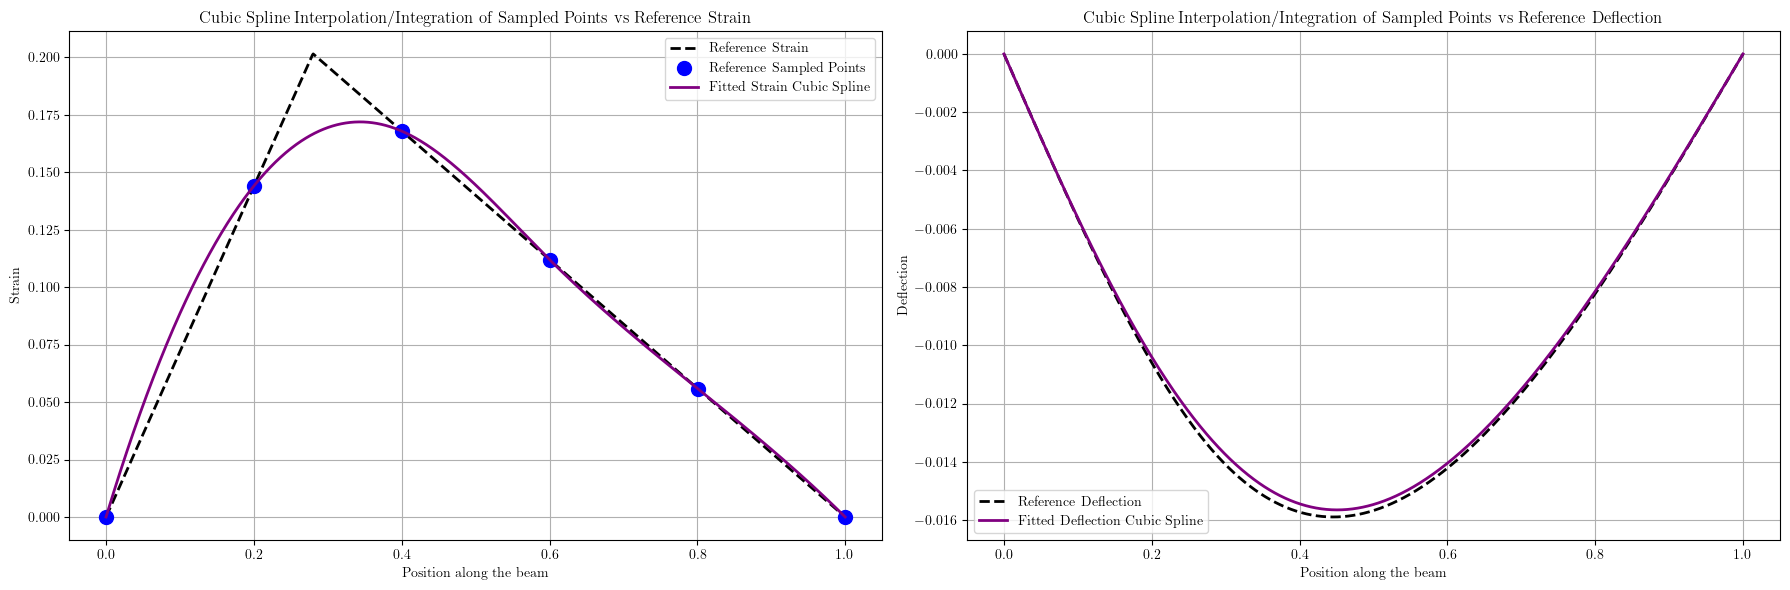

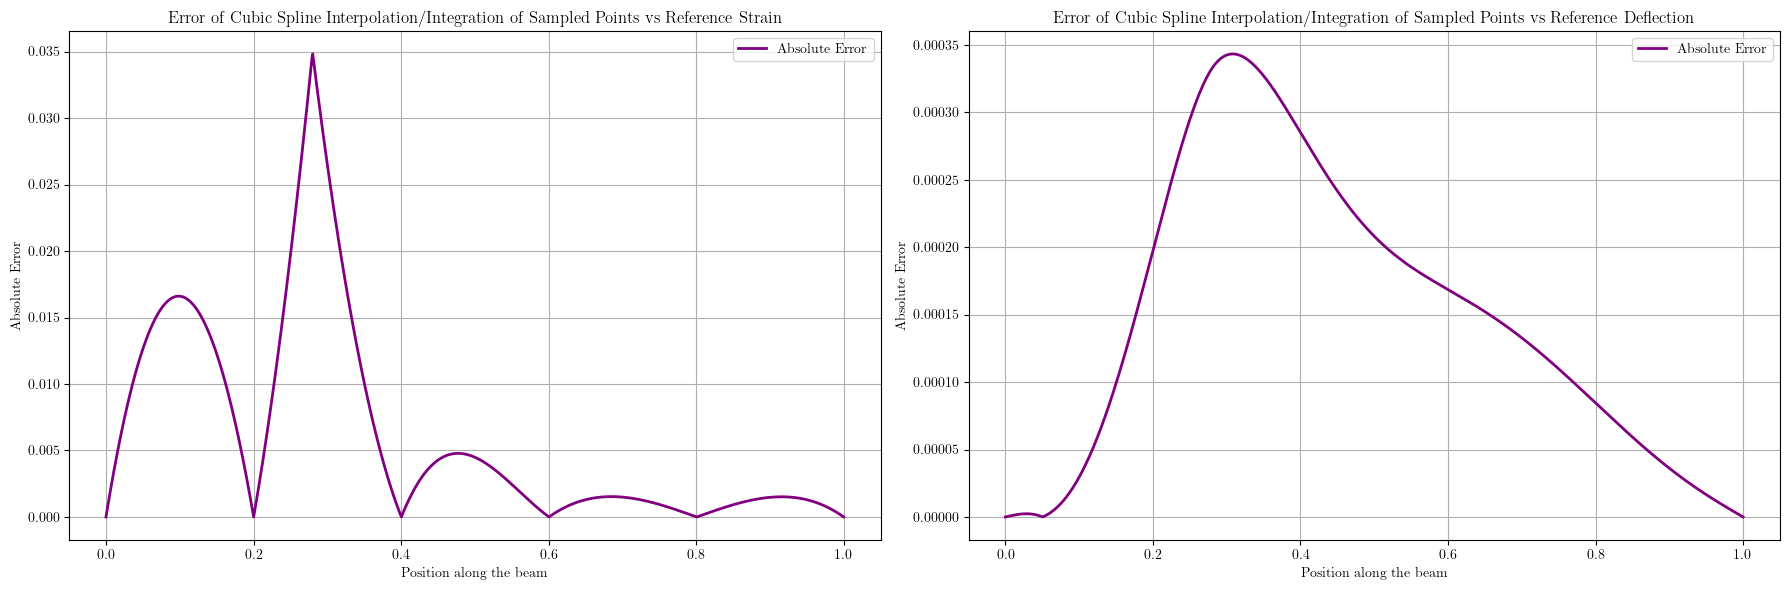

In [137]:
# n = int(l / delta)  # select points that are multiples of delta
x_sampled = np.append(x[::int(np.ceil( len(x) / n ))], l)
strain = np.append(M[::int(np.ceil( len(x) / n ))], 0)

cs_strain = sp.interpolate.CubicSpline(x_sampled, strain[::-1])
ad1 = cs_strain.antiderivative()
cs_slope = sp.interpolate.CubicSpline(x, ad1(x))
ad2 = cs_slope.antiderivative()
w_int_b = ad2(x) - ad2(x)[-1] / np.max(x) * x

cs_strain = sp.interpolate.CubicSpline(x_sampled, strain)
ad1 = cs_strain.antiderivative()
cs_slope = sp.interpolate.CubicSpline(x, ad1(x))
ad2 = cs_slope.antiderivative()
w_int_f = ad2(x) - ad2(x)[-1] / np.max(x) * x


w_avg = (w_int_b[::-1] + w_int_f) / 2


strain_poly = np.polynomial.Polynomial.fit(x_sampled, strain, deg=len(x_sampled)-1)

fig, ax = plt.subplots(1, 2,figsize=(18, 6))

ax[0].plot(x, M, label='Reference Strain', color='black', linewidth=2, linestyle='--')
ax[0].plot(x_sampled, strain, label='Reference Sampled Points', color='blue', linestyle='None', marker='o', markersize=10)
# ax[0].plot(x_sampled, strain_poly(x_sampled), label='Fitted Polynomial', color='red', linewidth=2)
ax[0].plot(x, cs_strain(x), label='Fitted Strain Cubic Spline', color='purple', linewidth=2)
ax[0].set_title('Cubic Spline Interpolation/Integration of Sampled Points vs Reference Strain')
ax[0].set_xlabel('Position along the beam')
ax[0].set_ylabel('Strain')
ax[0].legend()
ax[0].grid(True)
ax[1].plot(x, w, label='Reference Deflection', color='black', linewidth=2, linestyle='--')
ax[1].plot(x, w_int_f, label='Fitted Deflection Cubic Spline', color='purple', linewidth=2)
ax[1].set_title('Cubic Spline Interpolation/Integration of Sampled Points vs Reference Deflection')
ax[1].set_xlabel('Position along the beam')
ax[1].set_ylabel('Deflection')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

error_strain = np.abs(cs_strain(x) - M)

error_deflection = np.abs(w_int_f - w)


fig, ax = plt.subplots(1, 2,figsize=(18, 6))

ax[0].plot(x, error_strain, label='Absolute Error', color='purple', linewidth=2)
ax[0].set_title('Error of Cubic Spline Interpolation/Integration of Sampled Points vs Reference Strain')
ax[0].set_xlabel('Position along the beam')
ax[0].set_ylabel('Absolute Error')
ax[0].legend()
ax[0].grid(True)
ax[1].plot(x, error_deflection, label='Absolute Error', color='purple', linewidth=2)
ax[1].set_title('Error of Cubic Spline Interpolation/Integration of Sampled Points vs Reference Deflection')
ax[1].set_xlabel('Position along the beam')
ax[1].set_ylabel('Absolute Error')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

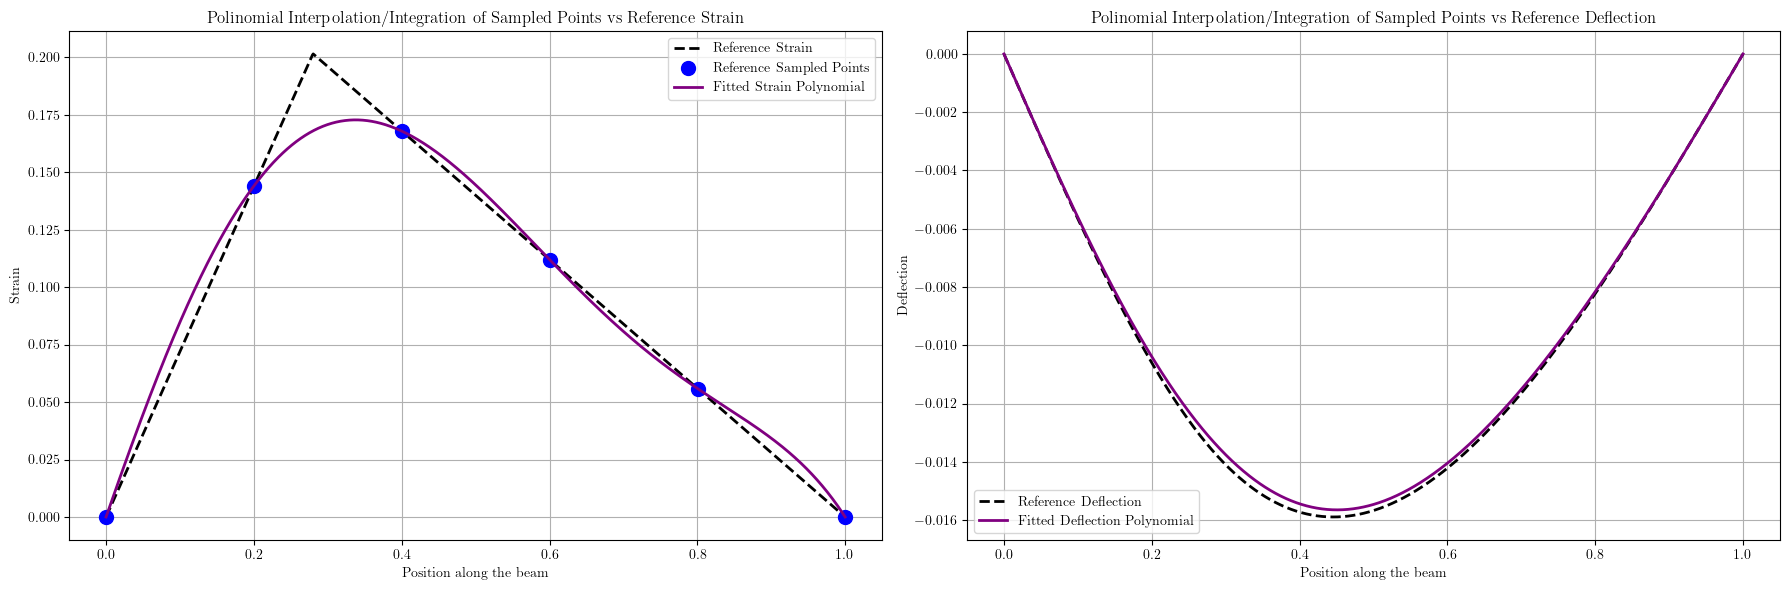

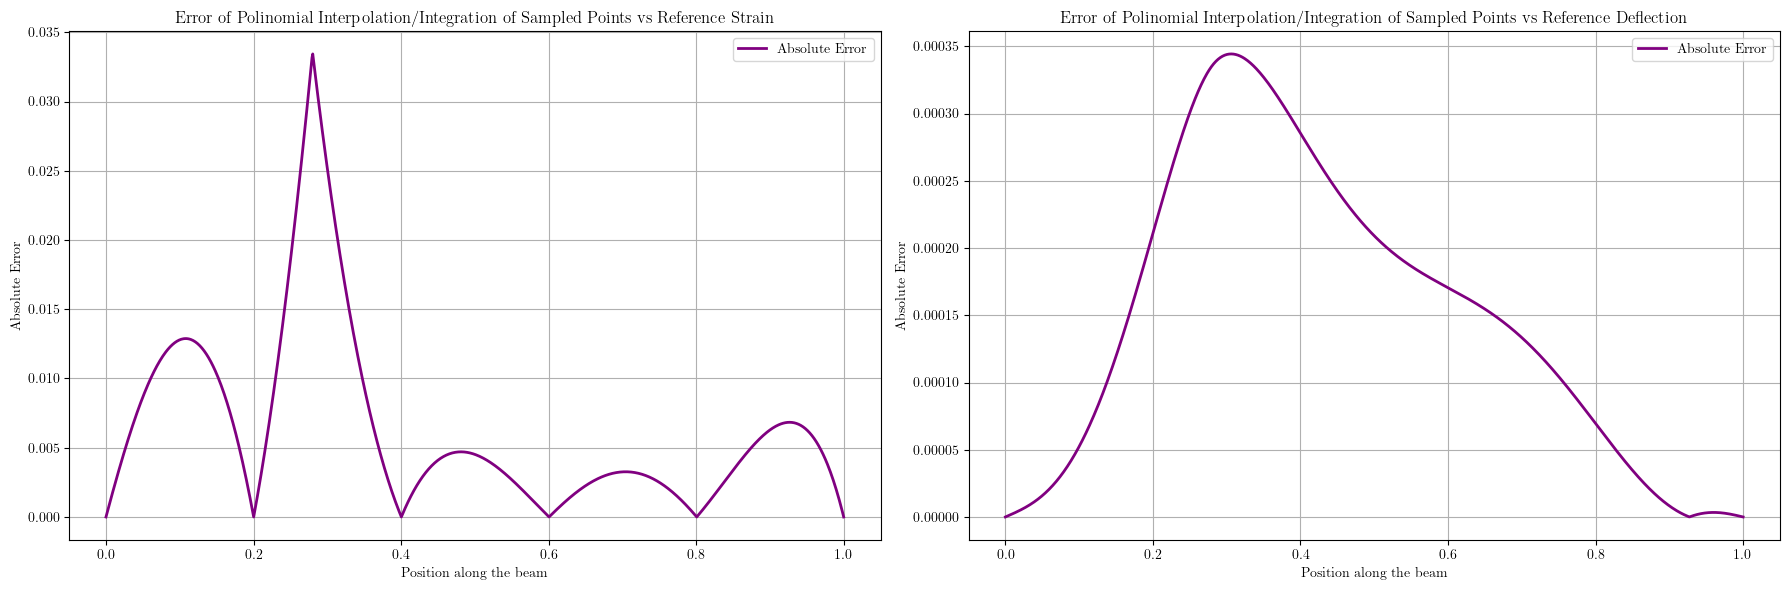

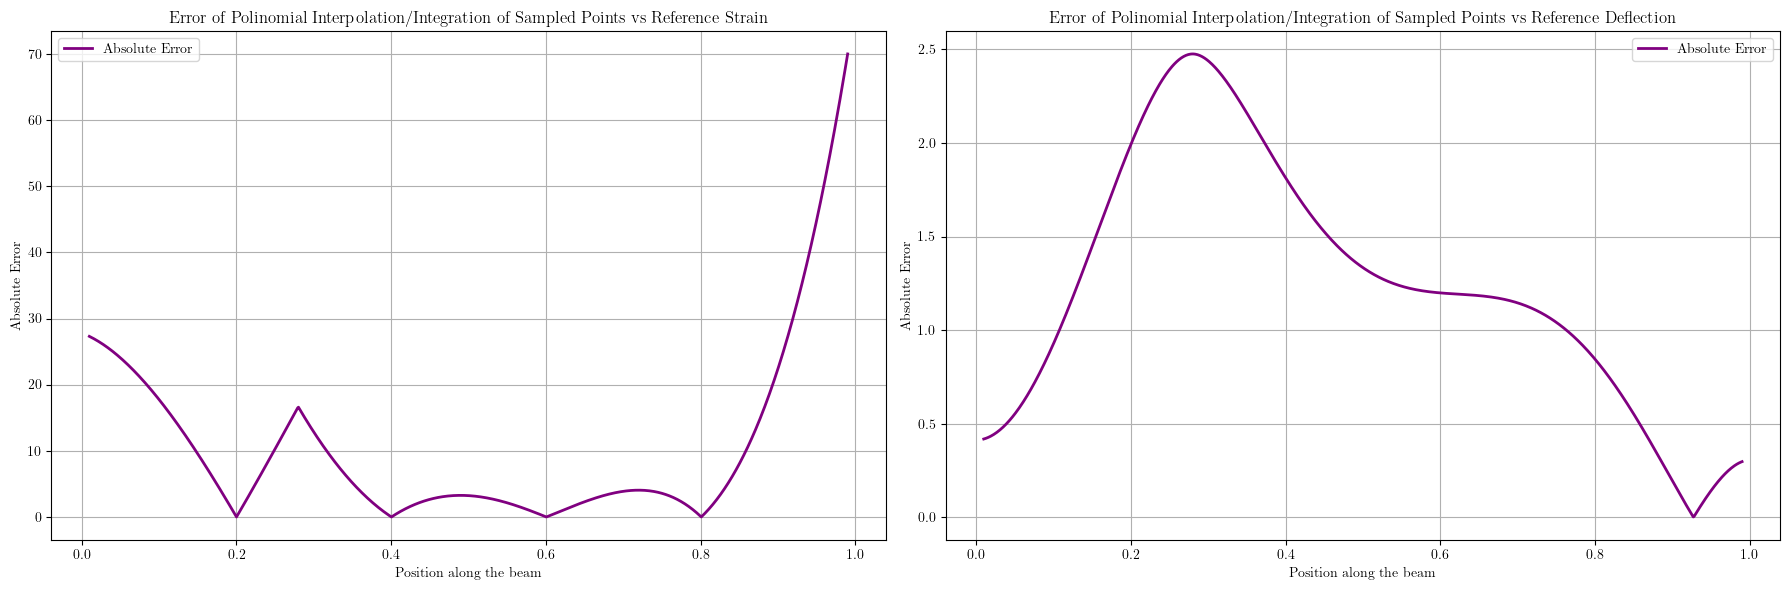

In [138]:
# delta = 0.33
# n = int(l / delta)  # select points that are multiples of delta
x_sampled = np.append(x[::int(np.ceil( len(x) / n ))], l)
strain = np.append(M[::int(np.ceil( len(x) / n ))], 0)

strain_poly = np.polynomial.Polynomial.fit(x_sampled, strain, deg=len(x_sampled)-1)
w_int_f = strain_poly.integ().integ()(x) - strain_poly.integ().integ()(x[0]) # double integral
w_int_f = w_int_f - w_int_f[-1] / np.max(x) * x # boudary condition w[a] == 0
# strain_poly = np.polyval(poly, x_sampled)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

ax[0].plot(x, M, label='Reference Strain', color='black', linewidth=2, linestyle='--')
ax[0].plot(x_sampled, strain, label='Reference Sampled Points', color='blue', linestyle='None', marker='o', markersize=10)
# ax[0].plot(x_sampled, strain_poly(x_sampled), label='Fitted Polynomial', color='red', linewidth=2)
ax[0].plot(x, strain_poly(x), label='Fitted Strain Polynomial', color='purple', linewidth=2)
ax[0].set_title('Polinomial Interpolation/Integration of Sampled Points vs Reference Strain')
ax[0].set_xlabel('Position along the beam')
ax[0].set_ylabel('Strain')
ax[0].legend()
ax[0].grid(True)
ax[1].plot(x, w, label='Reference Deflection', color='black', linewidth=2, linestyle='--')
ax[1].plot(x, w_int_f, label='Fitted Deflection Polynomial', color='purple', linewidth=2)
ax[1].set_title('Polinomial Interpolation/Integration of Sampled Points vs Reference Deflection')
ax[1].set_xlabel('Position along the beam')
ax[1].set_ylabel('Deflection')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

error_strain = np.abs(strain_poly(x) - M)

error_deflection = np.abs(w_int_f - w)


fig, ax = plt.subplots(1, 2,figsize=(18, 6))

ax[0].plot(x, error_strain, label='Absolute Error', color='purple', linewidth=2)
ax[0].set_title('Error of Polinomial Interpolation/Integration of Sampled Points vs Reference Strain')
ax[0].set_xlabel('Position along the beam')
ax[0].set_ylabel('Absolute Error')
ax[0].legend()
ax[0].grid(True)
ax[1].plot(x, error_deflection, label='Absolute Error', color='purple', linewidth=2)
ax[1].set_title('Error of Polinomial Interpolation/Integration of Sampled Points vs Reference Deflection')
ax[1].set_xlabel('Position along the beam')
ax[1].set_ylabel('Absolute Error')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2,figsize=(18, 6))

ax[0].plot(x[10:990], error_strain[10:990] / (np.abs(M[10:990])) *1e2, label='Absolute Error', color='purple', linewidth=2)
ax[0].set_title('Error of Polinomial Interpolation/Integration of Sampled Points vs Reference Strain')
ax[0].set_xlabel('Position along the beam')
ax[0].set_ylabel('Absolute Error')
ax[0].legend()
ax[0].grid(True)
ax[1].plot(x[10:990], np.abs(w - w_int_f)[10:990] / (np.abs(w[10:990]))*1e2, label='Absolute Error', color='purple', linewidth=2)
ax[1].set_title('Error of Polinomial Interpolation/Integration of Sampled Points vs Reference Deflection')
ax[1].set_xlabel('Position along the beam')
ax[1].set_ylabel('Absolute Error')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()